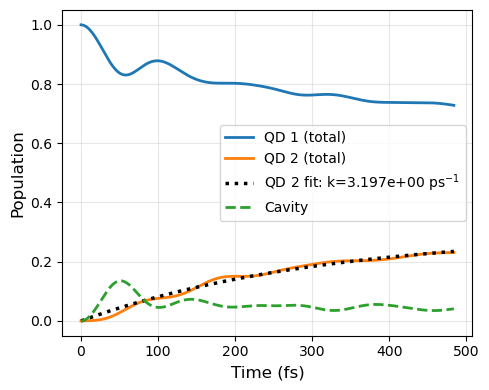

Max populations:
  QD 1: 1
  QD 2: 0.231047
  Cavity: 0.13538

QD2 exponential-rise fit:
  P_inf = 0.298364
  k     = 3.196582e+00 ps^-1
  tau   = 0.312834 ps

Total population (should be ~1): 1


In [1]:
#!/usr/bin/env python3
"""
Read and plot population data from pop.out.

State ordering for this TC example:
- States 0-3: QD 1 exciton states
- States 4-7: QD 2 exciton states
- State 8: cavity photon state
"""

import numpy as np
import matplotlib.pyplot as plt

autos = 2.4188843265857e-17
n_qd = 2
nstate_per_qd = 4
n_cavity = 1
n_qd_states = n_qd * nstate_per_qd

data = np.loadtxt("pop.out")
time = data[:, 0] * autos * 1e15  # au to fs
populations = data[:, 1:]
n_states = populations.shape[1]

if n_states != n_qd_states + n_cavity:
    raise ValueError(f"Expected {n_qd_states + n_cavity} states, found {n_states}")

# Extract QD and cavity populations
qd_pop = populations[:, :n_qd_states]
cavity_pop = populations[:, n_qd_states:]

# Sum population for each QD (across its nstate_per_qd states)
qd_total_pop = np.zeros((len(time), n_qd))
for qd in range(n_qd):
    start_idx = qd * nstate_per_qd
    end_idx = (qd + 1) * nstate_per_qd
    qd_total_pop[:, qd] = qd_pop[:, start_idx:end_idx].sum(axis=1)

# Fit QD2 population increase to P(t) = P_inf * (1 - exp(-k t)).
# This constrained form starts from exactly zero at time zero.
qd2_pop = qd_total_pop[:, 1]
fit_mask = (time > time[0]) & np.isfinite(qd2_pop)
t_fit = time[fit_mask]
y_fit = qd2_pop[fit_mask]

p_min = y_fit.max() + max(1e-8, 1e-6 * y_fit.max())
p_max = max(1.0, p_min * 1.2)
p_inf_grid = np.linspace(p_min, p_max, 2000)

best = None
for p_inf in p_inf_grid:
    scaled_residual = 1.0 - y_fit / p_inf
    if np.any(scaled_residual <= 0.0):
        continue
    log_residual = np.log(scaled_residual)
    k = -np.sum(t_fit * log_residual) / np.sum(t_fit**2)
    if k <= 0.0:
        continue
    y_model = p_inf * (1.0 - np.exp(-k * t_fit))
    sse = np.mean((y_model - y_fit) ** 2)
    if best is None or sse < best[0]:
        best = (sse, p_inf, k)

if best is None:
    raise RuntimeError("Could not fit QD2 population to an exponential increase")

_, p_inf_fit, k_fit = best
k_ps = k_fit * 1000.0  # fs^-1 -> ps^-1
tau_ps = 1.0 / k_ps
qd2_fit = p_inf_fit * (1.0 - np.exp(-k_fit * time))

fig, ax = plt.subplots(figsize=(5, 4))

# Plot total population for each QD
for qd in range(n_qd):
    ax.plot(time, qd_total_pop[:, qd], label=f"QD {qd + 1} (total)", linewidth=2)

ax.plot(time, qd2_fit, "k:", linewidth=2.5, label=f"QD 2 fit: k={k_ps:.3e} ps$^{{-1}}$")

# Plot cavity population
ax.plot(time, cavity_pop[:, 0], label="Cavity", linewidth=2, linestyle='--')

ax.set_xlabel("Time (fs)", fontsize=12)
ax.set_ylabel("Population", fontsize=12)
#ax.set_title("Population dynamics: QD states and cavity", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Max populations:")
for qd in range(n_qd):
    print(f"  QD {qd + 1}: {qd_total_pop[:, qd].max():.6g}")
print(f"  Cavity: {cavity_pop[:, 0].max():.6g}")
print("\nQD2 exponential-rise fit:")
print(f"  P_inf = {p_inf_fit:.6g}")
print(f"  k     = {k_ps:.6e} ps^-1")
print(f"  tau   = {tau_ps:.6g} ps")
print(f"\nTotal population (should be ~1): {(qd_total_pop.sum(axis=1) + cavity_pop.sum(axis=1)).mean():.6g}")


In [3]:
np.sum(populations[:, 12:14], axis=1)

array([2.74563358e-17, 1.55725648e-06, 1.10449800e-05, 2.85559604e-05,
       5.41609812e-05, 8.79097987e-05, 1.29830339e-04, 1.79927655e-04,
       2.38180794e-04, 3.04548339e-04, 3.78969130e-04, 4.61360559e-04,
       5.51621203e-04, 6.49625808e-04, 7.55228497e-04, 8.68264916e-04,
       9.88551072e-04, 1.11588446e-03, 1.25004932e-03, 1.39082085e-03,
       1.53795913e-03, 1.69121581e-03, 1.85033597e-03, 2.01505890e-03,
       2.18512050e-03, 2.36025103e-03, 2.54017983e-03, 2.72463544e-03,
       2.91334857e-03, 3.10605010e-03, 3.30246969e-03, 3.50233337e-03,
       3.70537174e-03, 3.91131665e-03, 4.11989822e-03, 4.33085165e-03,
       4.54391483e-03, 4.75883290e-03, 4.97535348e-03, 5.19322568e-03,
       5.41220143e-03, 5.63203961e-03, 5.85250880e-03, 6.07338750e-03,
       6.29446816e-03, 6.51555315e-03, 6.73645334e-03, 6.95699196e-03,
       7.17700689e-03, 7.39635194e-03, 7.61489592e-03, 7.83252640e-03,
       8.04914845e-03, 8.26468362e-03, 8.47907455e-03, 8.69228189e-03,
      